## 1. Introduction

En optimisation, on manipule souvent des **fonctions quadratiques** ou **polynomiales** écrites sous forme matricielle :

$$f(\mathbf{x}) = \frac{1}{2} \mathbf{x}^T A \mathbf{x} + \mathbf{b}^T \mathbf{x} + c$$
où $A \in \mathbb{R}^{n \times n}$ symétrique, $\mathbf{b} \in \mathbb{R}^n$, $c \in \mathbb{R}$.

Ce formalisme est essentiel pour :
- Les problèmes de **moindres carrés**
- Les **méthodes de Newton** en optimisation
- L’étude de la **convexité** (via $A$ semi-définie positive)

---

## 2. Rappel : développement de Taylor à l’ordre 2

Pour une fonction $f : \mathbb{R}^n \to \mathbb{R}$ deux fois différentiable, le **développement de Taylor** au voisinage de $\mathbf{x}_0$ est :

$$f(\mathbf{x}_0 + \mathbf{h}) = f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)^T \mathbf{h} + \frac{1}{2} \mathbf{h}^T H_f(\mathbf{x}_0) \mathbf{h} + o(\|\mathbf{h}\|^2)$$

Où :
- $\nabla f(\mathbf{x}_0)$ est le **gradient** (vecteur colonne)
- $H_f(\mathbf{x}_0)$ est la **matrice hessienne**

---

## 3. Cas d’un polynôme quadratique

Prenons la fonction :
$$f(\mathbf{x}) = \frac{1}{2} \mathbf{x}^T A \mathbf{x} + \mathbf{b}^T \mathbf{x} + c$$

On peut calculer explicitement :
$$\nabla f(\mathbf{x}) = A \mathbf{x} + \mathbf{b}$$
$$H_f(\mathbf{x}) = A$$

Le développement de Taylor autour de $\mathbf{x}_0$ devient :
$$f(\mathbf{x}_0 + \mathbf{h}) = f(\mathbf{x}_0) + (A\mathbf{x}_0 + \mathbf{b})^T \mathbf{h} + \frac{1}{2} \mathbf{h}^T A \mathbf{h}$$

Vérification par le code ci-dessous.

---

## 4. Illustration numérique

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Définition d'une fonction quadratique
n = 2
A = np.array([[3, 1],
              [1, 2]])  # symétrique définie positive
b = np.array([-2, -5])
c = 10

def f(x):
    return 0.5 * x.T @ A @ x + b.T @ x + c

def grad_f(x):
    return A @ x + b

def hess_f(x):
    return A  # constante pour un quadratique

# Point de développement
x0 = np.array([1.0, 2.0])

# Direction de perturbation
d = np.array([0.5, -0.3])

# Valeur exacte
f_exact = f(x0 + d)

# Approximation de Taylor à l'ordre 2
f_taylor2 = f(x0) + grad_f(x0).T @ d + 0.5 * d.T @ hess_f(x0) @ d

print(f"Valeur exacte          : {f_exact:.6f}")
print(f"Approximation Taylor 2 : {f_taylor2:.6f}")
print(f"Erreur                 : {abs(f_exact - f_taylor2):.2e}")

Valeur exacte          : 7.315000
Approximation Taylor 2 : 7.315000
Erreur                 : 8.88e-16


Pour un polynôme quadratique, l’approximation de Taylor à l’ordre 2 est **exacte** (pas de terme $o(\|\mathbf{h}\|^2)$).

---

## 5. Polynôme de degré 3 : exemple non exact

Prenons maintenant $g(\mathbf{x}) = x_1^3 + 2x_1 x_2 + x_2^2$ (forme non matricielle simple).

In [2]:
def g(x):
    return x[0]**3 + 2*x[0]*x[1] + x[1]**2

def grad_g(x):
    return np.array([3*x[0]**2 + 2*x[1],
                     2*x[0] + 2*x[1]])

def hess_g(x):
    return np.array([[6*x[0], 2],
                     [2,      2]])

x0 = np.array([1.0, 1.0])
d = np.array([0.2, -0.1])

g_exact = g(x0 + d)
g_taylor2 = g(x0) + grad_g(x0).T @ d + 0.5 * d.T @ hess_g(x0) @ d

print(f"Valeur exacte          : {g_exact:.6f}")
print(f"Approximation Taylor 2 : {g_taylor2:.6f}")
print(f"Erreur                 : {abs(g_exact - g_taylor2):.2e}")

Valeur exacte          : 4.698000
Approximation Taylor 2 : 4.690000
Erreur                 : 8.00e-03


Ici, l’approximation **n’est plus exacte** à cause du terme cubique (ordre 3).

---

## 6. Visualisation de l’approximation

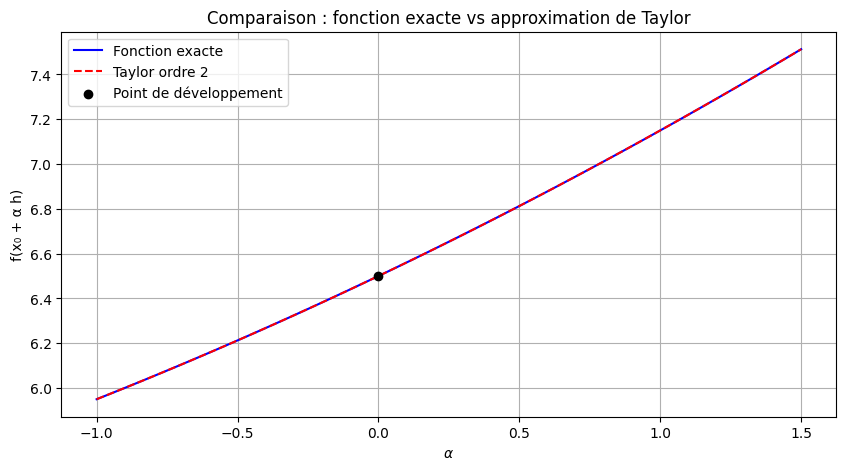

In [3]:
# Pour une fonction 1D le long de la direction d
def f_1d(alpha):
    return f(x0 + alpha * d)

def taylor2_1d(alpha):
    return f(x0) + alpha * grad_f(x0).T @ d + 0.5 * alpha**2 * d.T @ hess_f(x0) @ d

alpha_vals = np.linspace(-1, 1.5, 100)
f_vals = [f_1d(a) for a in alpha_vals]
taylor_vals = [taylor2_1d(a) for a in alpha_vals]

plt.figure(figsize=(10,5))
plt.plot(alpha_vals, f_vals, 'b-', label='Fonction exacte')
plt.plot(alpha_vals, taylor_vals, 'r--', label='Taylor ordre 2')
plt.scatter(0, f(x0), color='k', zorder=5, label='Point de développement')
plt.xlabel(r'$\alpha$')
plt.ylabel('f(x₀ + α h)')
plt.title('Comparaison : fonction exacte vs approximation de Taylor')
plt.legend()
plt.grid(True)
plt.show()

---

## 7. Utilité en optimisation

| Situation | Rôle de Taylor |
|-----------|----------------|
| **Descente de gradient** | Utilise l’approximation linéaire (ordre 1) |
| **Méthode de Newton** | Utilise l’approximation quadratique (ordre 2) |
| **Convexité** | Lien entre hessienne et coercivité |
| **Analyse de convergence** | Bornes via le reste de Taylor |

---

## 8. Synthèse

> **Sous forme matricielle, le développement de Taylor s’écrit :**
> $$f(\mathbf{x}_0 + \mathbf{h}) = f(\mathbf{x}_0) + (\nabla f(\mathbf{x}_0))^T \mathbf{h} + \frac{1}{2} \mathbf{h}^T H_f(\mathbf{x}_0) \mathbf{h} + o(\|\mathbf{h}\|^2)$$
> 
> - Pour un **quadratique**, cette formule est **exacte**.
> - La **matrice hessienne** $H_f(\mathbf{x}_0)$ est symétrique.
> - En optimisation, on utilise cette approximation pour construire des **modèles locaux** de la fonction.

---

## Exercice

> Soit $f(\mathbf{x}) = \mathbf{x}^T A \mathbf{x}$ avec $A = \begin{pmatrix} 2 & 1 \\ 1 & 3 \end{pmatrix}$.
> 
> 1. Calculer $\nabla f(\mathbf{x})$ et $H_f(\mathbf{x})$.
> 2. Écrire le développement de Taylor à l’ordre 2 autour de $\mathbf{x}_0 = (1, -1)^T$.
> 3. Vérifier numériquement que le reste est nul.